# Cyanobacteria D² Detection: Normalization Comparison
**442.5 nm vs 620 nm normalization wavelength**

This notebook tests how the choice of normalization wavelength affects:
1. The D² spectrum shape
2. The D² value at 552.5 nm (cyanobacteria detection wavelength)
3. The separation between diatom (April) and cyanobacteria (September) populations
4. What threshold would be needed under each normalization


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# phytospec imports
from phytospec.algorithms import compute_D2
from phytospec.io import load_datacube
from phytospec import config as cfg

print('Imports OK')

Imports OK


## 1. Load dataset
Load your existing dataset CSV which already has date, P_LUB, and rhow columns.
We will use:
- **April** spectra as diatom reference population
- **September** spectra as cyanobacteria reference population

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(cfg.RT1_DATASET_2024)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Extract wavelength grid from column names
rhow_cols = [c for c in df.columns if c.startswith('rhow_')]
wl = np.array([float(c.replace('rhow_', '')) for c in rhow_cols])
RHOW = df[rhow_cols].values

print(f'Dataset: {len(df)} days, {len(wl)} wavelengths')
print(f'Wavelength range: {wl[0]:.1f} – {wl[-1]:.1f} nm')
print(f'Months present: {sorted(df["month"].unique())}')

Dataset: 168 days, 237 wavelengths
Wavelength range: 355.0 – 945.0 nm
Months present: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_35232\2251361872.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df['date'].dt.month


In [3]:
# ── Define April (diatom) and September (cyano) subsets ──────────────────────
# Adjust months if your cyano bloom falls in a different month
mask_april = df['month'] == 4
mask_sept  = df['month'] == 9

print(f'April (diatom) spectra : {mask_april.sum()}')
print(f'September (cyano) spectra: {mask_sept.sum()}')

April (diatom) spectra : 20
September (cyano) spectra: 20


## 2. Compute D² under both normalizations
We compute D² for every spectrum using:
- `norm_wl=None` → 442.5 nm (index 35, current pipeline default)
- `norm_wl=620.0` → 620 nm (colleague's R convention)

In [4]:
N = len(df)
D2_442 = np.full((N, len(wl)), np.nan)
D2_620 = np.full((N, len(wl)), np.nan)

for i in range(N):
    rhow_i = RHOW[i, :]
    if np.sum(~np.isnan(rhow_i)) < 50:
        continue
    D2_442[i, :] = compute_D2(rhow_i, wl, norm_wl=None)    # 442.5 nm
    D2_620[i, :] = compute_D2(rhow_i, wl, norm_wl=620.0)   # 620 nm

print('D² computed for both normalizations')

D² computed for both normalizations


## 3. Extract D² value at 552.5 nm (cyanobacteria detection wavelength)

In [5]:
# Find index of 552.5 nm
idx_552 = int(np.argmin(np.abs(wl - 552.5)))
print(f'Detection wavelength: {wl[idx_552]:.1f} nm (index {idx_552})')

# Extract scalar D² at 552.5 nm for each spectrum
d2_552_442 = D2_442[:, idx_552]   # under 442.5 nm normalization
d2_552_620 = D2_620[:, idx_552]   # under 620 nm normalization

df['D2_552_norm442'] = d2_552_442
df['D2_552_norm620'] = d2_552_620

Detection wavelength: 552.5 nm (index 79)


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_35232\2272655364.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['D2_552_norm442'] = d2_552_442
C:\Users\gvillegas\AppData\Local\Temp\ipykernel_35232\2272655364.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['D2_552_norm620'] = d2_552_620


## 4. Plot 1 — Mean D² spectra for April vs September under each normalization

C:\Users\gvillegas\AppData\Local\Temp\ipykernel_35232\3597308246.py:10: RuntimeWarning: Mean of empty slice
  mean_d2 = np.nanmean(D2[mask, :], axis=0)
c:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


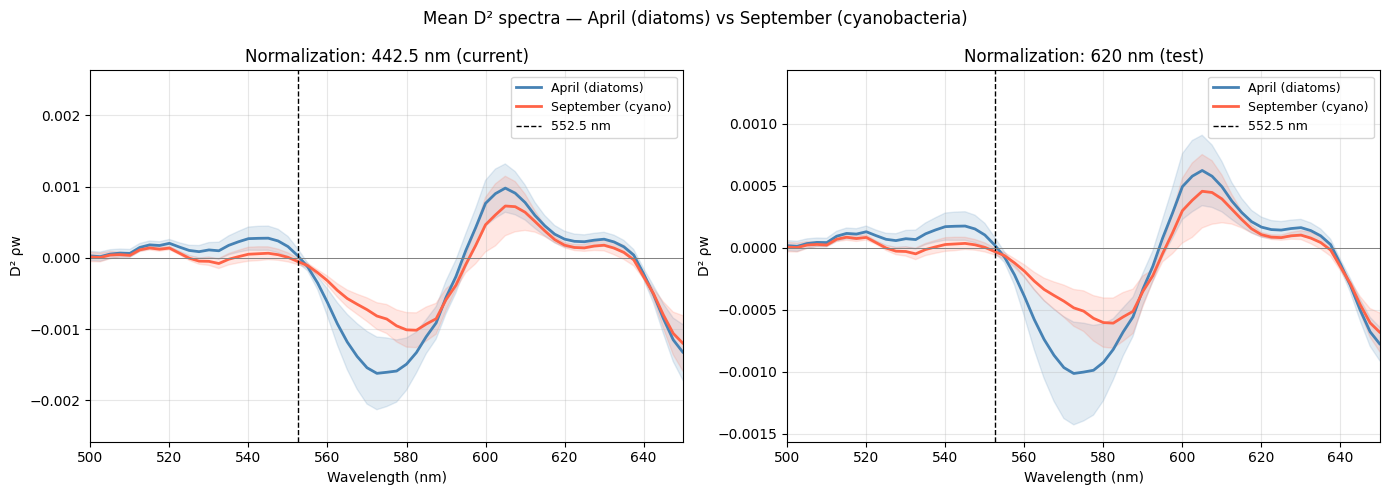

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

norm_labels = ['442.5 nm (current)', '620 nm (test)']
D2_list     = [D2_442, D2_620]
colors      = {'April (diatoms)': 'steelblue', 'September (cyano)': 'tomato'}
masks       = {'April (diatoms)': mask_april,  'September (cyano)': mask_sept}

for ax, D2, norm_label in zip(axes, D2_list, norm_labels):
    for label, mask in masks.items():
        mean_d2 = np.nanmean(D2[mask, :], axis=0)
        std_d2  = np.nanstd(D2[mask, :],  axis=0)
        ax.plot(wl, mean_d2, color=colors[label], label=label, linewidth=2)
        ax.fill_between(wl, mean_d2 - std_d2, mean_d2 + std_d2,
                        color=colors[label], alpha=0.15)

    ax.axvline(552.5, color='black', linestyle='--', linewidth=1, label='552.5 nm')
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_xlim(500, 650)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('D² ρw')
    ax.set_title(f'Normalization: {norm_label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Mean D² spectra — April (diatoms) vs September (cyanobacteria)', fontsize=12)
plt.tight_layout()
plt.savefig('d2_spectra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Plot 2 — Distribution of D² at 552.5 nm for both populations

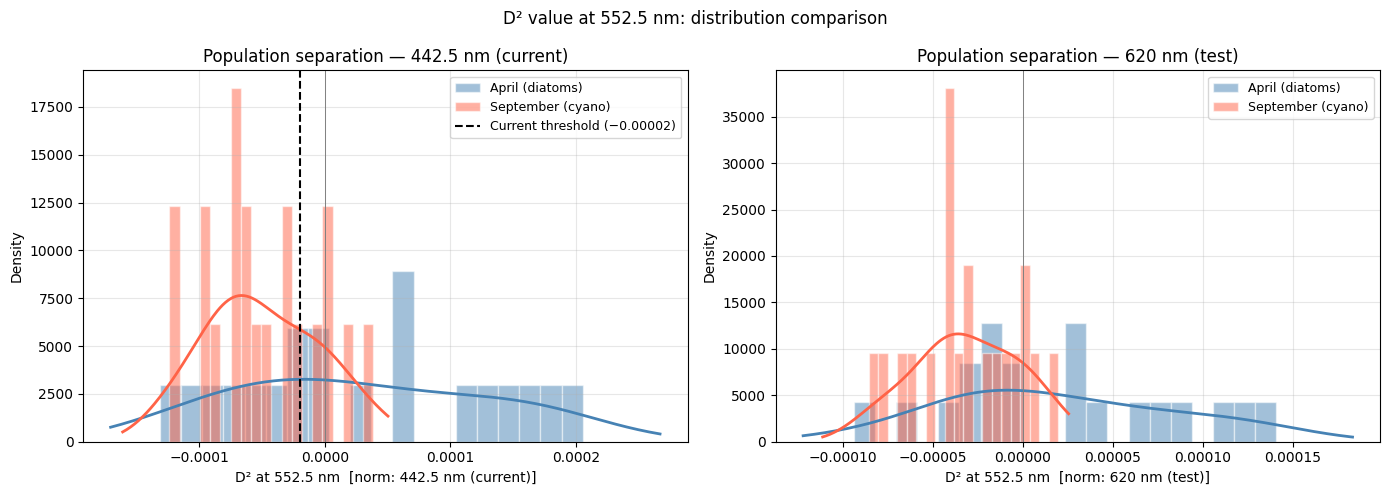

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

norm_labels  = ['442.5 nm (current)', '620 nm (test)']
d2_vals_list = [d2_552_442, d2_552_620]

for ax, d2_vals, norm_label in zip(axes, d2_vals_list, norm_labels):

    for label, mask, color in [
        ('April (diatoms)',    mask_april, 'steelblue'),
        ('September (cyano)', mask_sept,  'tomato')
    ]:
        vals = d2_vals[mask]
        vals = vals[~np.isnan(vals)]
        ax.hist(vals, bins=20, color=color, alpha=0.5, label=label,
                density=True, edgecolor='white')
        # overlay KDE
        if len(vals) > 3:
            kde  = gaussian_kde(vals)
            xmin, xmax = vals.min(), vals.max()
            xs   = np.linspace(xmin - abs(xmin)*0.3, xmax + abs(xmax)*0.3, 200)
            ax.plot(xs, kde(xs), color=color, linewidth=2)

    # Current threshold (valid only for 442.5 nm normalization)
    if '442' in norm_label:
        ax.axvline(-0.00002, color='black', linestyle='--',
                   linewidth=1.5, label='Current threshold (−0.00002)')

    ax.axvline(0, color='gray', linewidth=0.7)
    ax.set_xlabel(f'D² at 552.5 nm  [norm: {norm_label}]')
    ax.set_ylabel('Density')
    ax.set_title(f'Population separation — {norm_label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('D² value at 552.5 nm: distribution comparison', fontsize=12)
plt.tight_layout()
plt.savefig('d2_552_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Plot 3 — Time series of D² at 552.5 nm (full season)

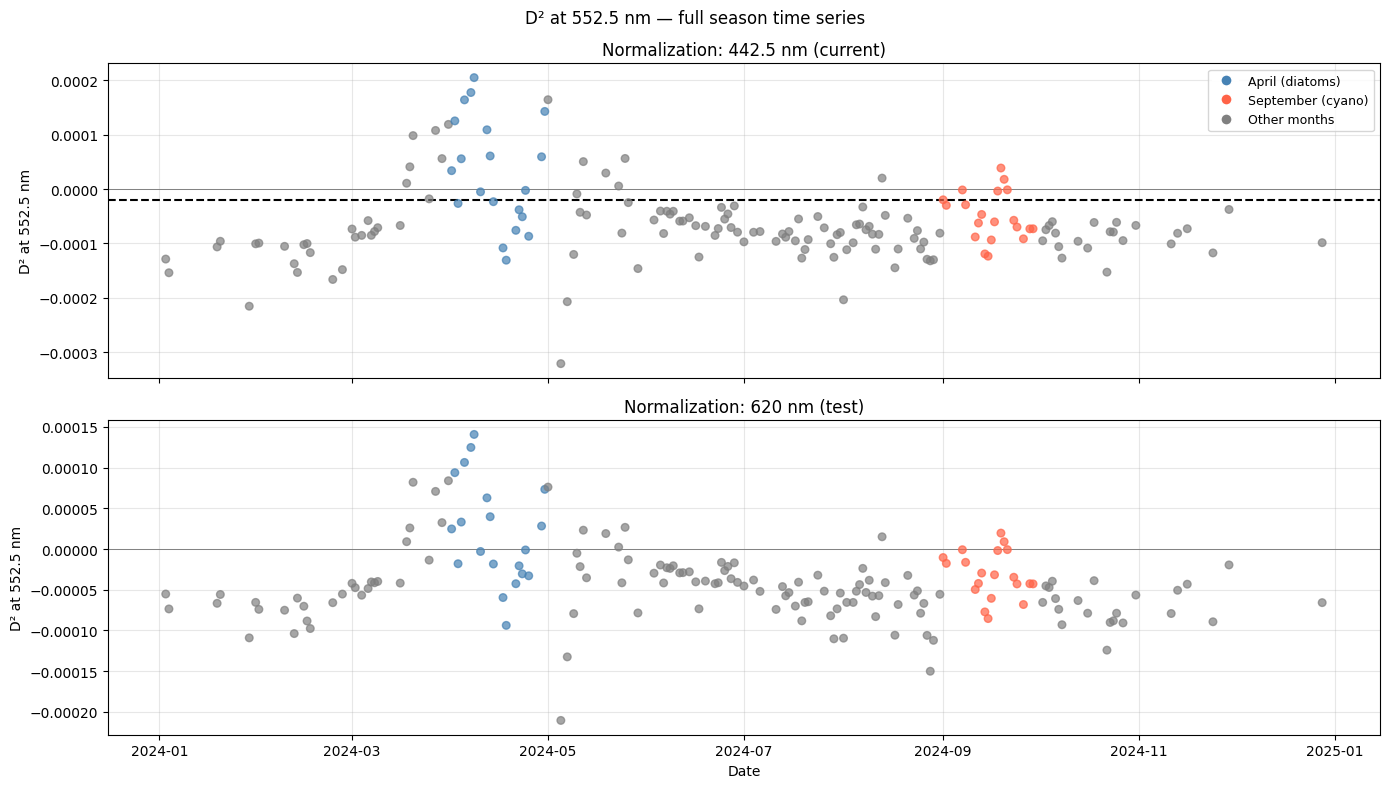

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, col, norm_label, threshold in [
    (axes[0], 'D2_552_norm442', '442.5 nm (current)', -0.00002),
    (axes[1], 'D2_552_norm620', '620 nm (test)',       None)
]:
    ax.scatter(df['date'], df[col],
               c=df['month'].map(lambda m: 'tomato' if m == 9 else
                                           'steelblue' if m == 4 else 'gray'),
               s=30, alpha=0.7, zorder=3)
    ax.axhline(0, color='gray', linewidth=0.7)
    if threshold is not None:
        ax.axhline(threshold, color='black', linestyle='--',
                   linewidth=1.5, label=f'Current threshold ({threshold})')
        ax.legend(fontsize=9)
    ax.set_ylabel('D² at 552.5 nm')
    ax.set_title(f'Normalization: {norm_label}')
    ax.grid(True, alpha=0.3)

# Legend for colours
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='April (diatoms)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='September (cyano)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',      markersize=8, label='Other months'),
]
axes[0].legend(handles=legend_elements, fontsize=9, loc='upper right')

axes[1].set_xlabel('Date')
fig.suptitle('D² at 552.5 nm — full season time series', fontsize=12)
plt.tight_layout()
plt.savefig('d2_552_timeseries_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quantitative summary — population statistics and separation

In [9]:
print('='*60)
print('D² at 552.5 nm — population statistics')
print('='*60)

for norm_label, col in [('442.5 nm', 'D2_552_norm442'), ('620 nm', 'D2_552_norm620')]:
    print(f'\nNormalization: {norm_label}')
    print(f'{"Population":<25} {"N":>5} {"Mean":>12} {"Std":>12} {"Min":>12} {"Max":>12}')
    print('-'*70)
    for label, mask in [('April (diatoms)', mask_april), ('September (cyano)', mask_sept)]:
        vals = df.loc[mask, col].dropna()
        print(f'{label:<25} {len(vals):>5} {vals.mean():>12.6f} {vals.std():>12.6f} '
              f'{vals.min():>12.6f} {vals.max():>12.6f}')

print('\n' + '='*60)
print('Separation ratio (|mean_cyano - mean_diatom| / pooled_std)')
print('Higher = better separation between populations')
print('='*60)

for norm_label, col in [('442.5 nm', 'D2_552_norm442'), ('620 nm', 'D2_552_norm620')]:
    cyano  = df.loc[mask_sept,  col].dropna()
    diatom = df.loc[mask_april, col].dropna()
    pooled_std = np.sqrt((cyano.std()**2 + diatom.std()**2) / 2)
    separation = abs(cyano.mean() - diatom.mean()) / pooled_std if pooled_std > 0 else np.nan
    print(f'  {norm_label}: separation ratio = {separation:.2f}')

D² at 552.5 nm — population statistics

Normalization: 442.5 nm
Population                    N         Mean          Std          Min          Max
----------------------------------------------------------------------
April (diatoms)              20     0.000029     0.000100    -0.000131     0.000205
September (cyano)            20    -0.000049     0.000045    -0.000124     0.000039

Normalization: 620 nm
Population                    N         Mean          Std          Min          Max
----------------------------------------------------------------------
April (diatoms)              20     0.000020     0.000064    -0.000094     0.000141
September (cyano)            20    -0.000031     0.000029    -0.000085     0.000020

Separation ratio (|mean_cyano - mean_diatom| / pooled_std)
Higher = better separation between populations
  442.5 nm: separation ratio = 1.01
  620 nm: separation ratio = 1.04


## 8. What threshold would be needed under 620 nm normalization?
Find the midpoint between the two population means as a naive threshold estimate.

In [10]:
print('Suggested threshold (midpoint between population means):')
print()

for norm_label, col in [('442.5 nm (current)', 'D2_552_norm442'),
                         ('620 nm (test)',       'D2_552_norm620')]:
    cyano  = df.loc[mask_sept,  col].dropna()
    diatom = df.loc[mask_april, col].dropna()
    midpoint = (cyano.mean() + diatom.mean()) / 2
    print(f'  {norm_label}:')
    print(f'    Mean cyano  = {cyano.mean():.6f}')
    print(f'    Mean diatom = {diatom.mean():.6f}')
    print(f'    Midpoint threshold = {midpoint:.6f}')
    print()

Suggested threshold (midpoint between population means):

  442.5 nm (current):
    Mean cyano  = -0.000049
    Mean diatom = 0.000029
    Midpoint threshold = -0.000010

  620 nm (test):
    Mean cyano  = -0.000031
    Mean diatom = 0.000020
    Midpoint threshold = -0.000006

